# A phantom microstructure

To test indexing we need a sample whose answer we know, and one that looks like the materials Anri is for.
`anri.phantom.polycrystal` makes a 2D slice of a polycrystal with the features that make real maps hard:

- **grains** with random orientations, from a Voronoi tessellation;
- **cells** of about 1.5 µm inside them (dislocation or solidification cells), each turned from its grain by a few tenths of a degree;
- **annealing twins**: lamellae with sharp boundaries, turned 60° about the grain's ⟨111⟩ (the Σ3 twin of FCC metals).

Orientations are piecewise constant on a grid finer than the scan step, so one scan voxel can hold several cells, or a parent and its twin.

Here we make a 316L-like stainless steel phantom (FCC, *a* = 3.5966 Å), turn it into an ImageD11 `TensorMap`, look at it, and save it to `tests/data`, where the tests and the [indexing tutorial](indexing.ipynb) use it.

This notebook is stored with its outputs and is not re-run when the docs are built.

In [1]:
import anri.utils

anri.utils.setup()  # before any JAX computation

import numpy as np
from matplotlib import pyplot as plt

import anri.crystal
import anri.io
import anri.phantom

## The microstructure

A disk of radius 25 µm on a grid of 0.5 µm voxels (103 × 103), with 40 grains, cells of about 1.5 µm misoriented by 0.3° (standard deviation of each component of the rotation vector), and twin lamellae 2 µm thick every 5 µm in the largest grain.

In [2]:
ph = anri.phantom.polycrystal(n=103, step=0.5, radius=25.0, n_grains=40, cell_size=1.5, cell_spread_deg=0.3,
                              twin_grains=1, twin_axis=(1, 1, 1), twin_angle_deg=60.0, twin_period=5.0,
                              twin_thickness=2.0, seed=0)
inside = ph["inside"]
print(f"{inside.sum()} voxels in the disk, {len(np.unique(ph['grain'][inside]))} grains, "
      f"{len(np.unique(ph['cell'][inside]))} cells, {ph['twin'].sum()} twin voxels")

7845 voxels in the disk, 38 grains, 721 cells, 253 twin voxels


## Symmetry and misorientations

`anri.crystal.laue_rotations` gives the 24 proper rotations of the cubic Laue group, as Cartesian matrices in the crystal frame: `U` and `U S` give the same reflections.
Misorientations are taken over them with `anri.crystal.disorientation`.

Each cell is a small rotation away from its grain, and each twin is 60° away from its parent: let's check.

24 Laue-group rotations


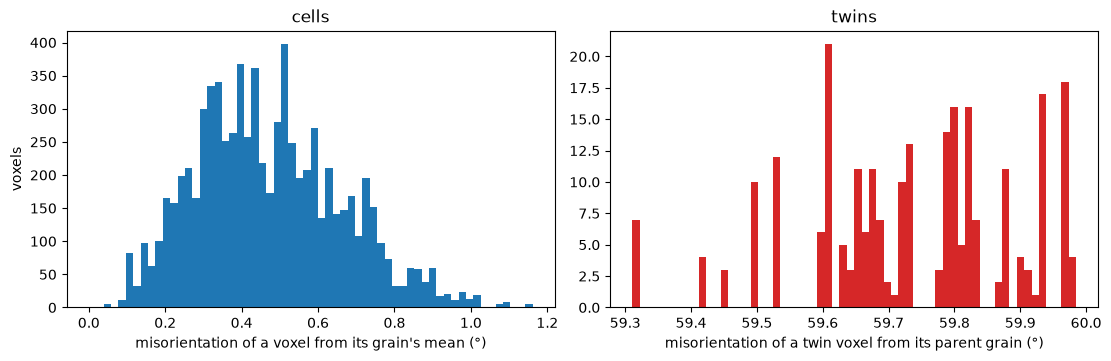

In [3]:
a = 3.5966
B = anri.crystal.B_matrix([a, a, a, 90.0, 90.0, 90.0])
ops = anri.crystal.laue_rotations(anri.crystal.symmetry_matrices(225), B)
print(f"{len(ops)} Laue-group rotations")

U = ph["U"].reshape(-1, 3, 3)
grain, twin = ph["grain"].ravel(), ph["twin"].ravel()
# each grain's mean orientation, from its non-twin voxels (cells are within a degree, so a plain mean works)
mean_U = {}
for g in np.unique(grain[grain >= 0]):
    u, _, vt = np.linalg.svd(U[(grain == g) & ~twin].mean(0))
    mean_U[g] = u @ vt
mis = np.full(len(U), np.nan)
ins = inside.ravel()
mis[ins] = anri.crystal.disorientation(U[ins], np.stack([mean_U[g] for g in grain[ins]]), ops)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5), layout="constrained")
ax[0].hist(mis[ins & ~twin], bins=60, color="tab:blue")
ax[0].set_xlabel("misorientation of a voxel from its grain's mean (°)")
ax[0].set_ylabel("voxels")
ax[0].set_title("cells")
ax[1].hist(mis[twin], bins=60, color="tab:red")
ax[1].set_xlabel("misorientation of a twin voxel from its parent grain (°)")
ax[1].set_title("twins")
plt.show()

## As a TensorMap

`anri.io.tensormap_from_recon` takes maps in reconstruction order and builds an ImageD11 `TensorMap`, so the phantom can be viewed and used like any map ImageD11 makes.
Next to the `UBI` and the phase, we store the grain (`labels`), cell and twin maps.

In [4]:
UBI = np.where(inside[..., None, None], np.linalg.inv(ph["U"] @ B), np.nan)
maps = {"UBI": UBI, "phase_ids": np.where(inside, 0, -1), "labels": ph["grain"], "cell": ph["cell"],
        "twin": ph["twin"].astype(np.int8), "misorientation": mis.reshape(inside.shape)}
tmap = anri.io.tensormap_from_recon(maps, [a, a, a, 90.0, 90.0, 90.0], 225, "316L", 0.5)
tmap.get_ipf_maps()
print(tmap.shape, tmap.steps, tmap.phases)

(1, 103, 103) [0.5, 0.5, 0.5] {0: 316L | [ 3.5966  3.5966  3.5966 90.     90.     90.    ] | 225}


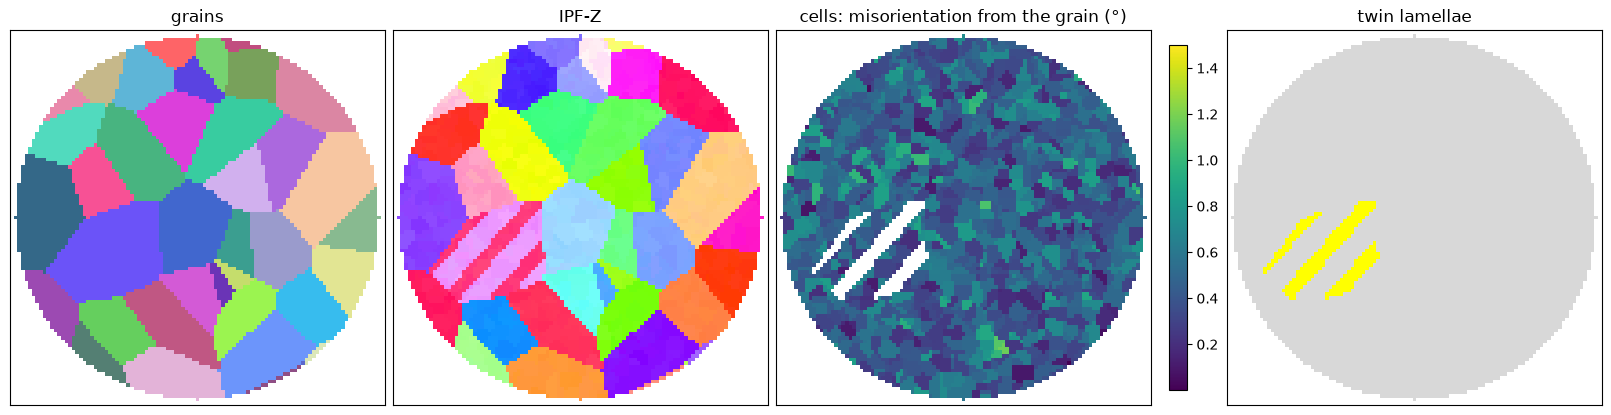

In [5]:
rng = np.random.default_rng(1)
colours = rng.uniform(0.2, 1.0, (tmap.labels.max() + 1, 3))
labels = tmap.labels[0]
grain_rgb = np.where(labels[..., None] >= 0, colours[np.maximum(labels, 0)], 1.0)

fig, ax = plt.subplots(1, 4, figsize=(16, 4.4), layout="constrained")
ax[0].imshow(grain_rgb, origin="lower")
ax[0].set_title("grains")
ax[1].imshow(np.where(labels[..., None] >= 0, tmap.ipf_z[0], 1.0), origin="lower")
ax[1].set_title("IPF-Z")
im = ax[2].imshow(np.where(tmap.twin[0] == 1, np.nan, tmap.misorientation[0]), origin="lower", cmap="viridis", vmax=1.5)
ax[2].set_title("cells: misorientation from the grain (°)")
fig.colorbar(im, ax=ax[2], shrink=0.8)
ax[3].imshow(np.where(labels[..., None] >= 0, 0.85, 1.0) * np.ones(3), origin="lower")
ax[3].imshow(np.ma.masked_where(tmap.twin[0] == 0, tmap.twin[0]), origin="lower", cmap="autumn", vmin=0, vmax=1)
ax[3].set_title("twin lamellae")
for a_ in ax:
    a_.set_xticks([]), a_.set_yticks([])
plt.show()

## Save it

The phantom is saved where the tests and the other notebooks find it.

In [6]:
import os

out = os.path.join("..", "..", "..", "tests", "data", "phantoms", "am316l", "am316l_tmap.h5")
if os.path.exists(out):
    os.remove(out)
tmap.to_h5(out)
print(f"{out}: {os.path.getsize(out) / 1e6:.1f} MB")

../../../tests/data/phantoms/am316l/am316l_tmap.h5: 1.0 MB
